## 1 - Imports and paths

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from lexos.dtm import DTM, Vectorizer
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from lexos.classification import trainer
import lexos.corpus.corpus_stats as cs

BASE = Path.cwd() # gets cwd, run this notebook from doc_src/docs/tutorials/classification
DATA = BASE / "fed_papers"

print("Base:", BASE)
print("Data dir exists:", DATA.exists())

Base: c:\Users\gabal\LocalFiles\Lexos_Independant_Research\lexos\doc_src\docs\tutorials\classification
Data dir exists: True


## 2) Collect train and test files

In [3]:
train_dirs = ["HAMILTON", "MADISON"]
test_dirs = ["COAUTHORED", "DISPUTED"]

train_files = []
for d in train_dirs:
    train_files.extend(sorted((DATA / d).glob("*.txt")))

test_files = []
for d in test_dirs:
    test_files.extend(sorted((DATA / d).glob("*.txt")))

print("Train files:", len(train_files), "Test files:", len(test_files))
assert train_files and test_files, "No files found; check working directory and folder structure."

Train files: 65 Test files: 15


### 2.1 Sort files by filename

In [4]:
train_files = sorted(train_files, key=lambda x: x.name)
test_files = sorted(test_files, key=lambda x: x.name)

## 3) Scrubber + Tokenizer

In [5]:
from lexos.scrubber.scrubber import Scrubber
from lexos.tokenizer import Tokenizer

scrubber = Scrubber()
scrubber.add_pipe("lower_case")
scrubber.add_pipe("digits")
scrubber.add_pipe("punctuation")

tokenizer = Tokenizer(model="en_core_web_sm")  # or any installed model

## 4) Build docs for CorpusStats (train + test)

In [6]:
from lexos.corpus.corpus_stats import CorpusStats

docs_for_corpus_stats = []  # For CorpusStats
docs_for_dtm = []  # For DTM
raw_texts = []
sets_list = []
all_files = [*train_files, *test_files]

for f in all_files:
    raw = f.read_text(encoding="utf-8")
    clean = scrubber.scrub(raw)
    spacy_doc = tokenizer(clean)
    tokens = [t.text for t in spacy_doc if t.text.strip()]
    doc_id = f.name
    docs_for_corpus_stats.append((doc_id, doc_id, tokens))
    docs_for_dtm.append(tokens) #DTM does not accept tuples
    raw_texts.append(raw)  # Enables char_count if CorpusStats uses raw_texts
    sets_list.append(f.parent.name)

# Generate CorpusStats
stats = CorpusStats(docs=docs_for_corpus_stats, raw_texts=raw_texts)
stats_df = stats.doc_stats_df.copy()
stats_df.insert(0, "document_set", sets_list)

## 5) Generating DTM

In [7]:
vectorizer = Vectorizer(max_features=500)  # Adjust max_features as needed
dtm = DTM(vectorizer=vectorizer)  # Initialize DTM with the vectorizer
dtm(docs=docs_for_dtm, labels=[doc[0] for doc in docs_for_dtm])  # Call the DTM object with docs and labels
dtm_df = pd.DataFrame(dtm.doc_term_matrix.toarray(), columns=dtm.sorted_terms_list)

## 6 - Combine CorpusStats features with DTM features

In [8]:
# Reset indices to ensure alignment
stats_df = stats_df.reset_index(drop=True)
dtm_df = dtm_df.reset_index(drop=True)

# Combine the DataFrames
combined_df = pd.concat([stats_df, dtm_df], axis=1)
combined_df = pd.concat([stats_df, dtm_df], axis=1)

# display(combined_df.head())
# print("Combined features:", list(combined_df.columns))
print("Shape of dtm_df:", dtm_df.shape)
print("Shape of stats_df:", stats_df.shape)
print("Shape of combined_df:", combined_df.shape)

Shape of dtm_df: (80, 8568)
Shape of stats_df: (80, 6)
Shape of combined_df: (80, 8574)


In [9]:
# 5) Select feature columns from combined_df
feature_cols = [
   "hapax_legomena",
    "total_tokens",
    "total_terms",
    "vocabulary_density",
    "hapax_dislegomena",
] + list(dtm_df.columns)  

train_mask = combined_df["document_set"].isin(["HAMILTON", "MADISON"])
test_mask  = combined_df["document_set"].isin(["COAUTHORED", "DISPUTED"])

X_train = combined_df.loc[train_mask, feature_cols].values
y_train = combined_df.loc[train_mask, "document_set"].values

X_test = combined_df.loc[test_mask, feature_cols].values
test_doc_ids = combined_df.loc[test_mask].index
test_sets = combined_df.loc[test_mask, "document_set"].values

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (65, 8573) Test: (15, 8573)


In [ ]:
clf = trainer.fit_classifier(
    X_train,
    y_train,
    model="decision_tree",
    random_state=42,
    min_samples_leaf=3,
    min_samples_split=5,
    max_depth=10,
    normalize=
)

print("Train accuracy:", clf.score(X_train, y_train))

Train accuracy: 0.9846153846153847


In [19]:
# 8) Predictions and evaluation on test set
y_pred_test = clf.predict(X_test)

# Create prediction DataFrame
pred_df = pd.DataFrame({
    "doc_id": combined_df.loc[train_mask].index,
    "set": combined_df.loc[train_mask, "document_set"].values,
    "pred_author": clf.predict(X_train)
})

print("Predictions on Test Set:")
display(pred_df)

# Count predictions by document set
print("\nPrediction Summary:")
print(pred_df.groupby(["set", "pred_author"]).size().unstack(fill_value=0))


Predictions on Test Set:


,doc_id,set,pred_author
0,0,MADISON,MADISON
1,1,HAMILTON,HAMILTON
2,2,HAMILTON,MADISON
3,3,HAMILTON,HAMILTON
4,4,MADISON,MADISON
...,...,...,...
60,60,HAMILTON,HAMILTON
61,61,HAMILTON,HAMILTON
62,62,HAMILTON,HAMILTON
63,63,HAMILTON,HAMILTON



Prediction Summary:
pred_author  HAMILTON  MADISON
set                           
HAMILTON           50        1
MADISON             0       14


,feature,importance
8171,upon,0.87809
3964,importation,0.12191
8541,wretched,0.00000
28,abraham,0.00000
8557,years,0.00000
...,...,...
8552,wyoming,0.00000
8553,xerxes,0.00000
8554,xiv,0.00000
8555,yates,0.00000


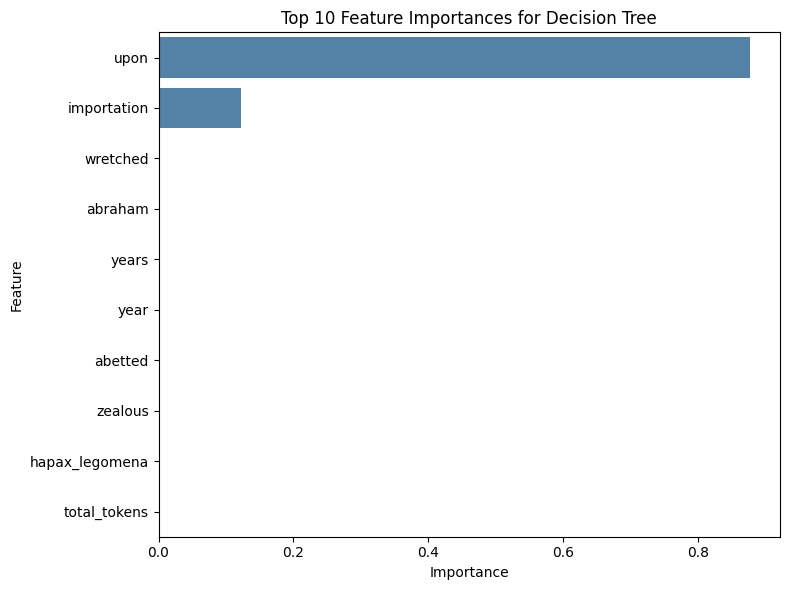

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Get feature importances from the trained decision tree
imp = clf.feature_importances_

# Create a DataFrame for feature importances
imp_df = pd.DataFrame({"feature": feature_cols, "importance": imp}).sort_values("importance", ascending=False)

# Display the DataFrame
display(imp_df)

# Select the top 10 features
top_10_features = imp_df.head(10)

# Plot the top 10 feature importances
plt.figure(figsize=(8, 6))
sns.barplot(data=top_10_features, x="importance", y="feature", color="steelblue")
plt.title("Top 10 Feature Importances for Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

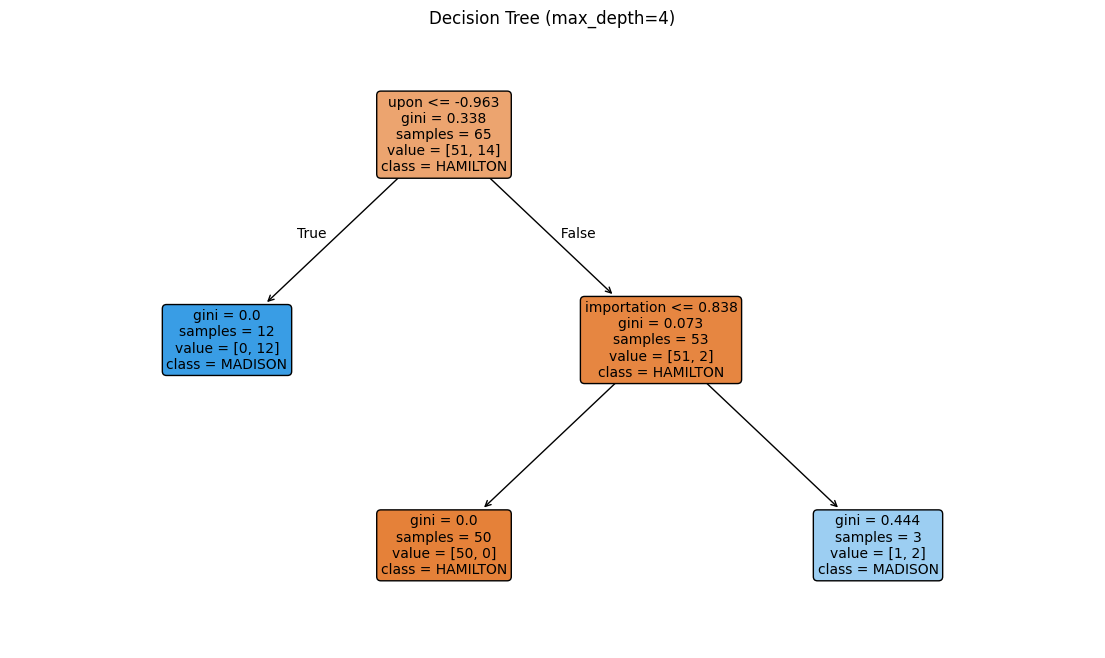

In [13]:
# 9) Visualize the tree
from sklearn.tree import plot_tree
plt.figure(figsize=(14,8))
plot_tree(
    clf,
    feature_names=feature_cols,
    class_names=sorted(set(y_train)),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree (max_depth=4)")
plt.show()

In [14]:
# 10) Predict on COAUTHORED / DISPUTED
y_pred_test = clf.predict(X_test)

pred_df = pd.DataFrame({
    "doc_id": test_doc_ids,
    "set": test_sets,
    "pred_author": y_pred_test
}).sort_values(["set", "doc_id"])

display(pred_df)
print("\nPrediction counts by set:")
print(pred_df.groupby(["set", "pred_author"]).size())

coauthored_preds = pred_df[pred_df["set"] == "COAUTHORED"]
print(f"\nCOAUTHORED papers - Predicted as HAMILTON: {(coauthored_preds['pred_author'] == 'HAMILTON').sum()}")
print(f"COAUTHORED papers - Predicted as MADISON: {(coauthored_preds['pred_author'] == 'MADISON').sum()}")

# For DISPUTED papers (historical consensus suggests Madison wrote most/all)
disputed_preds = pred_df[pred_df["set"] == "DISPUTED"]
print(f"\nDISPUTED papers - Predicted as HAMILTON: {(disputed_preds['pred_author'] == 'HAMILTON').sum()}")
print(f"DISPUTED papers - Predicted as MADISON: {(disputed_preds['pred_author'] == 'MADISON').sum()}")

,doc_id,set,pred_author
0,65,COAUTHORED,HAMILTON
1,66,COAUTHORED,HAMILTON
2,67,COAUTHORED,HAMILTON
3,68,DISPUTED,HAMILTON
4,69,DISPUTED,HAMILTON
5,70,DISPUTED,HAMILTON
6,71,DISPUTED,HAMILTON
7,72,DISPUTED,HAMILTON
8,73,DISPUTED,HAMILTON
9,74,DISPUTED,HAMILTON



Prediction counts by set:
set         pred_author
COAUTHORED  HAMILTON        3
DISPUTED    HAMILTON       12
dtype: int64

COAUTHORED papers - Predicted as HAMILTON: 3
COAUTHORED papers - Predicted as MADISON: 0

DISPUTED papers - Predicted as HAMILTON: 12
DISPUTED papers - Predicted as MADISON: 0
